# Block 8 — Evaluating Models: Advanced Metrics + Day 1 Tie-Together
### Advanced Machine Learning — M&T Bank

**Dataset:** `bank_marketing_features.csv` (unchanged since Block 3). Same feature prep and train/test split as
Blocks 4-7. No new CSV comes out of this block.

A short block — two more metrics, both chosen because they answer questions the ones we already have don't:

1. **Lift & cumulative gain** — if the call center can only work through part of the list, how much better is
   "call our model's top picks" than "call in whatever order"? Directly answers a campaign-targeting question none
   of Blocks 6-7's metrics were built to answer.
2. **Log-loss & Brier score** — do the *probabilities* themselves mean anything, not just the classifications they
   produce at some threshold?

Then a fast recap of the throughline connecting Blocks 2 through 7.


## Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Data source: https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing_features.csv
df = pd.read_csv("https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing_features.csv", sep=";")

# Same prep and split as Blocks 4-7
feature_cols = [c for c in df.columns if c not in ("education", "y", "duration")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]
numeric_to_scale = [
    "age", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
    "education_rank", "month_sin", "month_cos", "campaign_intensity",
    "emp.var.rate_denoised", "cons.price.idx_denoised", "cons.conf.idx_denoised",
    "euribor3m_denoised", "nr.employed_denoised",
]

X = df[feature_cols].copy()
for c in bool_cols:
    X[c] = X[c].astype(int)
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_test_s[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

model = LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)
model.fit(X_train_s, y_train)
proba = model.predict_proba(X_test_s)[:, 1]

print(f"Test set: {len(y_test)} clients, {y_test.sum()} actual subscribers ({y_test.mean():.1%})")


## 1. Lift & Cumulative Gain

**The question:** if the call center ranks every client by our model's predicted probability and works down the
list, how much of the list do they actually need to get through most of the real subscribers?

Sort the test set by predicted probability, descending, then track what fraction of the *actual* subscribers have
been captured as we move down the ranked list.


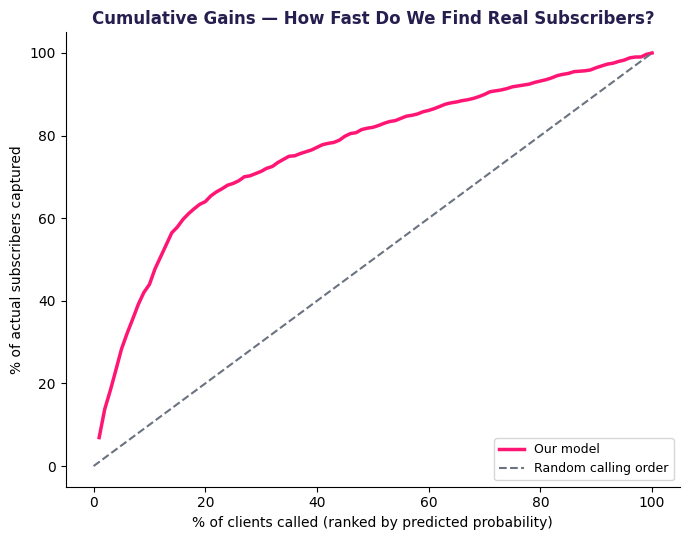

In [2]:
order = np.argsort(-proba)
y_sorted = y_test[order]
n = len(y_sorted)
total_pos = int(y_sorted.sum())
cum_pos = np.cumsum(y_sorted)

pcts = np.arange(1, 101) / 100
cum_capture = np.array([cum_pos[int(n * p) - 1] / total_pos for p in pcts])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(pcts * 100, cum_capture * 100, color=PINK, linewidth=2.5, label="Our model")
ax.plot([0, 100], [0, 100], color=GRAY, linestyle="--", linewidth=1.5, label="Random calling order")
ax.set_xlabel("% of clients called (ranked by predicted probability)")
ax.set_ylabel("% of actual subscribers captured")
ax.set_title("Cumulative Gains — How Fast Do We Find Real Subscribers?", color=NAVY, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [3]:
lift_rows = []
for pct in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    k = int(n * pct)
    captured = int(cum_pos[k - 1])
    capture_rate = captured / total_pos
    lift_rows.append({
        "% of list called": f"{int(pct*100)}%",
        "Clients called": k,
        "Subscribers captured": f"{captured} / {total_pos}",
        "% of all subscribers found": f"{capture_rate:.1%}",
        "Lift over random": f"{capture_rate / pct:.2f}x",
    })
pd.DataFrame(lift_rows)


,% of list called,Clients called,Subscribers captured,% of all subscribers found,Lift over random
0,5%,411,263 / 928,28.3%,5.67x
1,10%,823,408 / 928,44.0%,4.40x
2,20%,1647,594 / 928,64.0%,3.20x
3,30%,2471,662 / 928,71.3%,2.38x
4,40%,3295,716 / 928,77.2%,1.93x
5,50%,4119,761 / 928,82.0%,1.64x


**Calling just the top 10% of the ranked list (823 clients) catches 44% of every real subscriber in the test set —
a 4.4x lift over calling in random order.** By the top 20%, that's 64% of subscribers found. This is a much more
directly actionable number for a call-center operations conversation than ROC-AUC or even F1 — it answers "how much
of the list can we skip" in terms a campaign manager thinks in already.


## 2. Log-Loss & Brier Score — Do the Probabilities Themselves Mean Anything?

Every metric so far — precision, recall, F1, even ROC-AUC — only cares about the *ranking* or the classification at
some threshold. Neither checks whether a client the model scores at 0.70 actually converts about 70% of the time.
Log-loss and Brier score are **proper scoring rules**: they reward predicted probabilities that are honestly
calibrated, and penalize overconfidence, not just wrong rankings.


In [4]:
model_logloss = log_loss(y_test, proba)
model_brier = brier_score_loss(y_test, proba)

# Baseline: predict the training base rate for every single client, no model at all
base_rate = y_train.mean()
baseline_proba = np.full_like(proba, base_rate)
baseline_logloss = log_loss(y_test, baseline_proba)
baseline_brier = brier_score_loss(y_test, baseline_proba)

pd.DataFrame({
    "Metric": ["Log-loss (lower is better)", "Brier score (lower is better)"],
    "Our model": [model_logloss, model_brier],
    "Baseline (predict base rate for everyone)": [baseline_logloss, baseline_brier],
}).round(4)


,Metric,Our model,Baseline (predict base rate for everyone)
0,Log-loss (lower is better),0.2751,0.352
1,Brier score (lower is better),0.0777,0.100


Both come in well below the base-rate baseline — confirming the model's probabilities carry real, usable
information beyond just "11.3% of people subscribe," not only that its *rankings* are useful. Worth knowing which
proper scoring rule to reach for: log-loss penalizes confident wrong answers far more harshly (it's unbounded as a
predicted probability approaches 0 or 1 on the wrong side), while Brier score is bounded and easier to explain to a
non-technical stakeholder as "average squared error of the probability."


## 3. Day 1 Tie-Together: One Model, Six Blocks

Every number in this notebook came from the same `LogisticRegression(C=0.5)`, on the same `bank_marketing_features.csv`,
on the same train/test split — built up one deliberate decision at a time.


In [5]:
timeline = pd.DataFrame([
    ["Block 2", "Diagnosed missingness by mechanism (MCAR/MAR/MNAR), not just volume", "bank_marketing_clean.csv"],
    ["Block 3", "Engineered features (binning, encoding, cyclical) + PCA-denoised the macro group", "bank_marketing_features.csv"],
    ["Block 4", "Quantified duration's leakage (0.936 vs. 0.796 AUC); watched L1 vs. L2 handle redundant features", "no new CSV"],
    ["Block 5", "Found Block 4's single-split AUC (0.796) was optimistic vs. its own 5-fold mean (0.783)", "no new CSV"],
    ["Block 6", "Put a number on the accuracy trap (+1.2 pts over doing nothing); tuning barely moved AUC", "no new CSV"],
    ["Block 7", "Threshold tuning beat class-weighting on F1; four-fifths check failed regardless of threshold", "no new CSV"],
    ["Block 8", "Lift/gain: top 10% of the list catches 44% of subscribers; probabilities are honestly calibrated", "no new CSV"],
], columns=["Block", "What it added", "Dataset artifact"])
timeline


,Block,What it added,Dataset artifact
0,Block 2,Diagnosed missingness by mechanism (MCAR/MAR/M...,bank_marketing_clean.csv
1,Block 3,"Engineered features (binning, encoding, cyclic...",bank_marketing_features.csv
2,Block 4,Quantified duration's leakage (0.936 vs. 0.796...,no new CSV
3,Block 5,Found Block 4's single-split AUC (0.796) was o...,no new CSV
4,Block 6,Put a number on the accuracy trap (+1.2 pts ov...,no new CSV
5,Block 7,Threshold tuning beat class-weighting on F1; f...,no new CSV
6,Block 8,Lift/gain: top 10% of the list catches 44% of ...,no new CSV


**The throughline:** every evaluation choice in Blocks 4-8 was really the same question asked from a different
angle — *is this number telling us the truth, or just a convenient one?* Accuracy lied about how good the model was
(Block 6). A single train/test split lied about how stable that number is (Block 5). The default 0.5 threshold hid
a recall problem (Block 7). ROC-AUC looked fine while a leaky feature inflated it (Block 4). None of these are
model *failures* — they're reminders that a metric only means what its assumptions let it mean.

Two blocks left on Day 1: **Handling Outliers** — the one major data-quality question this whole model-evaluation
arc has deliberately deferred (`campaign` and `duration`'s extreme values are still sitting in the data, untouched
since Block 2).
